# Prise en main des TSFMs — Forecasting

> **Objectif :** prévoir la consommation électrique horaire à J+1 avec trois **Time Series Foundation Models** (TSFMs) utilisés en **zero-shot** — aucun entraînement sur nos données — et les comparer à des baselines naïves.

| Modèle | Équipe | Paramètres | Covariables |
|---|---|---|---|
| [**TS-ICL**](https://github.com/EDF-Lab/ts-icl) | EDF R&D | ~27 M | passées + futures |
| [**Chronos-2**](https://huggingface.co/amazon/chronos-2) | Amazon | ~120 M | passées + futures |
| [**TiRex-2**](https://github.com/NX-AI/tirex-2) | NXAI | ~38 M (univarié) / ~82 M | passées + futures |

Les trois modèles sont **probabilistes** : ils renvoient des quantiles, pas seulement une prévision ponctuelle.

### Au programme
0. [Données](#data)
1. [Protocole d'évaluation](#protocol)
2. [Baselines naïves](#baselines)
3. [Forecasting sans covariable](#no-covariate)
4. [Forecasting avec covariables](#covariates)
5. [Influence de la taille de contexte](#context-length)
6. [Bilan](#results)

## Imports

In [23]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from tsicl.pipeline import TSICL
from chronos import Chronos2Pipeline
from tirex2 import TimeseriesType, load_model

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}  |  device: {device}")

# Dossier contenant les 3 checkpoints (voir README)
CKPT_DIR = Path("../checkpoints")

# Légendes : plus grandes, encadrées, centrées sous chaque graphique
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({"legend.fontsize": 14, "legend.frameon": True, "legend.framealpha": 1,
                     "legend.edgecolor": "0.7", "legend.fancybox": False})

def legend_below(ax, handles=None, labels=None, ncol=None, **kwargs):
    # Place la légende sous l'axe, juste en dessous des graduations et du label de l'axe x.
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    fig      = ax.figure
    renderer = fig.canvas.get_renderer()
    box      = ax.get_window_extent(renderer)
    gap      = (box.y0 - ax.get_tightbbox(renderer).y0) / fig.dpi + 0.08          # en pouces
    entry    = (max(len(l) for l in labels) * 0.55 * plt.rcParams["legend.fontsize"] + 45) / 72   # largeur d'une entrée (pouces)
    ncol     = ncol or min(len(labels), max(1, int(box.width / fig.dpi / entry)))
    return ax.legend(handles, labels, loc="upper center", ncol=ncol, bbox_to_anchor=(0.5, 0),
                     bbox_transform=ax.transAxes + ScaledTranslation(0, -gap, fig.dpi_scale_trans), **kwargs)

PyTorch 2.9.1  |  device: cpu


<a id="data"></a>

---
## 0. Données

Le dataset `vic_electricity` ([tsibbledata](https://tsibbledata.tidyverts.org/reference/vic_elec.html)) contient la **demande électrique semi-horaire** de l'État de Victoria (Australie) de 2012 à 2014, avec :
- `Temperature` — température à Melbourne
- `Holiday` — indicateur de jour férié

Comme dans le [tutoriel skforecast](https://cienciadedatos.net/documentos/py79-forecasting-with-foundation-models.html), on agrège au **pas horaire**. On travaille en heure locale (Melbourne) pour que les cycles journaliers et les jours fériés soient bien alignés.

In [24]:
DATA_PATH = Path("../data/vic_electricity.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Time"])
df = (
    df.set_index("Time")
      .tz_convert("Australia/Melbourne").tz_localize(None)   # UTC -> heure locale
      .drop(columns="Date")
      .resample("h").mean()
      .interpolate()                                         # 3 heures manquantes (passage à l'heure d'été)
      .loc["2012-01-01":"2014-12-30"]
)
print(f"{df.shape[0]} pas horaires  |  {df.index.min()}  ->  {df.index.max()}")
df.head()

26280 pas horaires  |  2012-01-01 00:00:00  ->  2014-12-30 23:00:00


,Demand,Temperature,Holiday
Time,,,
2012-01-01 00:00:00,4323.095350,21.225,1.0
2012-01-01 01:00:00,3963.264688,20.625,1.0
2012-01-01 02:00:00,3950.913495,20.325,1.0
2012-01-01 03:00:00,3627.860675,19.850,1.0
2012-01-01 04:00:00,3396.251676,19.025,1.0


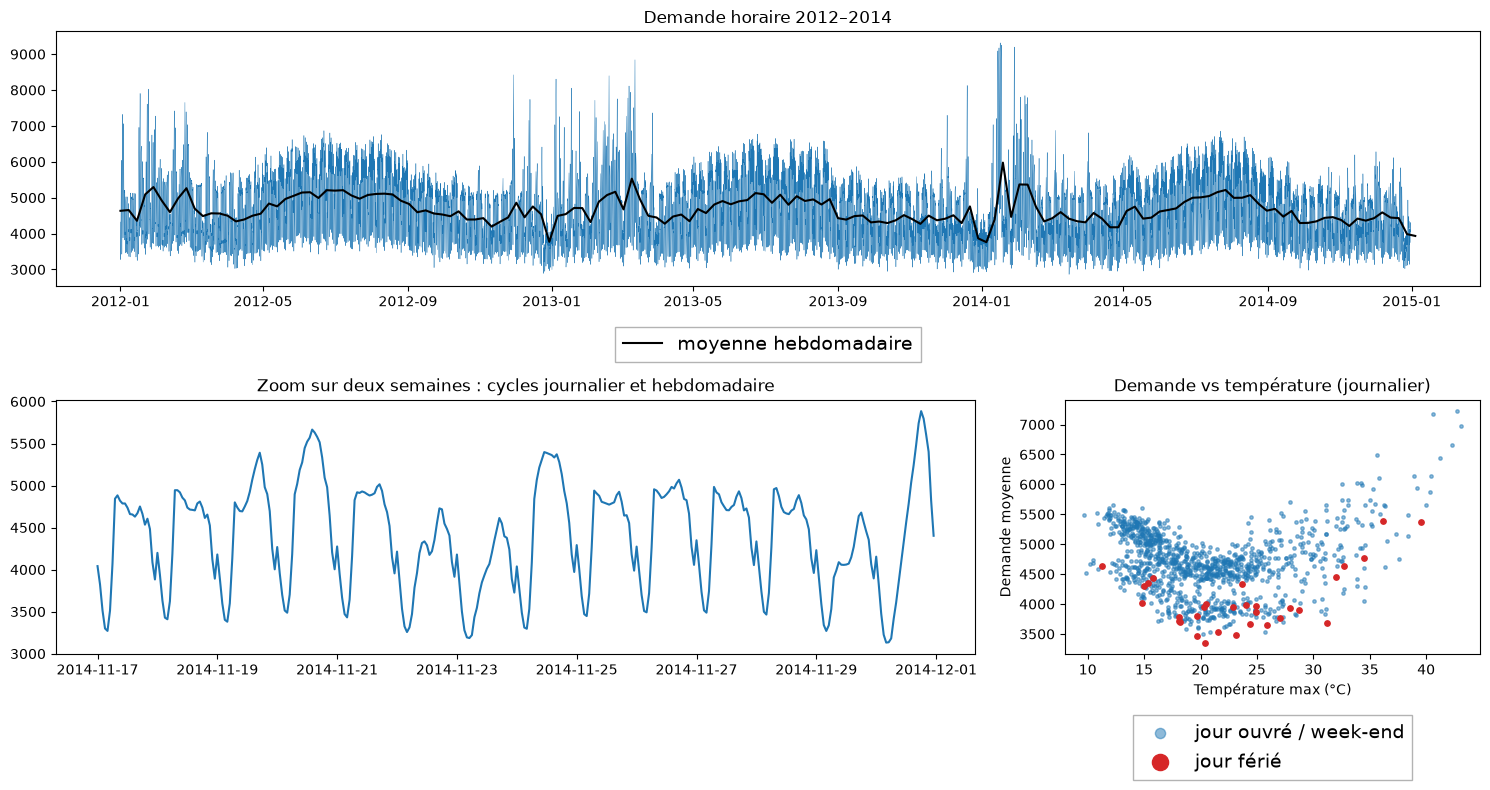

In [25]:
fig = plt.figure(figsize=(15, 8))
gs  = fig.add_gridspec(2, 3)

ax = fig.add_subplot(gs[0, :])
ax.plot(df.index, df["Demand"], lw=0.3, color="tab:blue")
ax.plot(df["Demand"].resample("W").mean(), lw=1.5, color="k", label="moyenne hebdomadaire")
ax.set_title("Demande horaire 2012–2014")
legend_below(ax)

ax = fig.add_subplot(gs[1, :2])
week = df.loc["2014-11-17":"2014-11-30"]
ax.plot(week.index, week["Demand"], color="tab:blue")
ax.set_title("Zoom sur deux semaines : cycles journalier et hebdomadaire")

ax = fig.add_subplot(gs[1, 2])
daily = df.resample("D").agg({"Demand": "mean", "Temperature": "max", "Holiday": "max"})
ax.scatter(daily["Temperature"], daily["Demand"], s=6, alpha=0.5, label="jour ouvré / week-end")
ax.scatter(*daily.loc[daily["Holiday"] == 1, ["Temperature", "Demand"]].T.values, s=15, color="tab:red", label="jour férié")
ax.set_xlabel("Température max (°C)")
ax.set_ylabel("Demande moyenne")
ax.set_title("Demande vs température (journalier)")
legend_below(ax, markerscale=3)

plt.tight_layout()
plt.show()

La relation demande / température est **non linéaire** (chauffage l'hiver, climatisation l'été) et les jours fériés font chuter la demande : ce seront nos **covariables** en partie 4.

<a id="protocol"></a>

---
## 1. Protocole d'évaluation

- **Horizon** `H = 24` : prévision J+1, lancée chaque jour à minuit
- **Contexte** : chaque modèle reçoit le **maximum d'historique qu'il sait exploiter** (influence étudiée en [partie 5](#context-length))

| Modèle | Contexte max | Soit |
|---|---|---|
| TS-ICL | 4 096 h | ~24 semaines |
| Chronos-2 | 8 192 h | ~49 semaines |
| TiRex-2 | 8 192 h | ~49 semaines (2 048 par défaut, à relever via `context_len`, voir 3.3) |

- **Backtest** : 30 prévisions J+1 par modèle, une par jour de décembre 2014 (période de test du tutoriel skforecast)
- **Quantiles** : 0.1, 0.2, …, 0.9 (sortie native de TiRex-2, on aligne les autres modèles dessus)

In [26]:
H = 24
quantile_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

TSFMS       = ["TS-ICL", "Chronos-2", "TiRex-2"]
CONTEXT_MAX = {"TS-ICL": 4096, "Chronos-2": 8192, "TiRex-2": 8192}

y     = df["Demand"].to_numpy(dtype=np.float32)
X     = df[["Temperature", "Holiday"]].to_numpy(dtype=np.float32)
dates = df.index

test_start = dates.get_loc(pd.Timestamp("2014-12-01"))
origins    = np.arange(test_start, len(df), H)          # une origine par jour

def make_context(L, origins=origins):
    return np.stack([y[o - L : o] for o in origins])          # [N, L]

def make_covars(L, origins=origins):
    return np.stack([X[o - L : o + H] for o in origins])      # [N, L+H, K] : contexte + horizon

y_true = np.stack([y[o : o + H] for o in origins])            # [N, H]

print(f"{len(origins)} prévisions J+1 x {H} h = {y_true.size} points horaires évalués par modèle")

30 prévisions J+1 x 24 h = 720 points horaires évalués par modèle


#### Combien de prévisions fait-on ?

Pour la période de test principale, chaque modèle produit **30 prévisions** : une prévision J+1 (24 h) lancée chaque jour à minuit, du 1er au 30 décembre 2014. À chaque origine, le modèle ne voit que l'historique **avant** minuit (pas de fuite d'information), puis on avance d'un jour.

Cela fait **30 × 24 = 720 points horaires prévus par modèle** : toutes les métriques (MAE, RMSE, WQL, couverture) sont calculées sur ces 720 points.

Sur l'ensemble du notebook :

| Partie | Configurations | Prévisions J+1 |
|---|---|---|
| 2. Baselines (J-1, J-7) | 2 | 60 |
| 3. Sans covariable (3 modèles) | 3 | 90 |
| 4. Avec covariables (3 modèles) | 3 | 90 |
| 5. Étude de contexte (6 + 7 + 7 valeurs de `L`) | 20 | 600 |
| **Total** | **28** | **840** |

> 30 prévisions sur un seul mois (atypique : Noël, canicules), c'est peu : des écarts de quelques unités de MAE entre modèles relèvent du bruit.

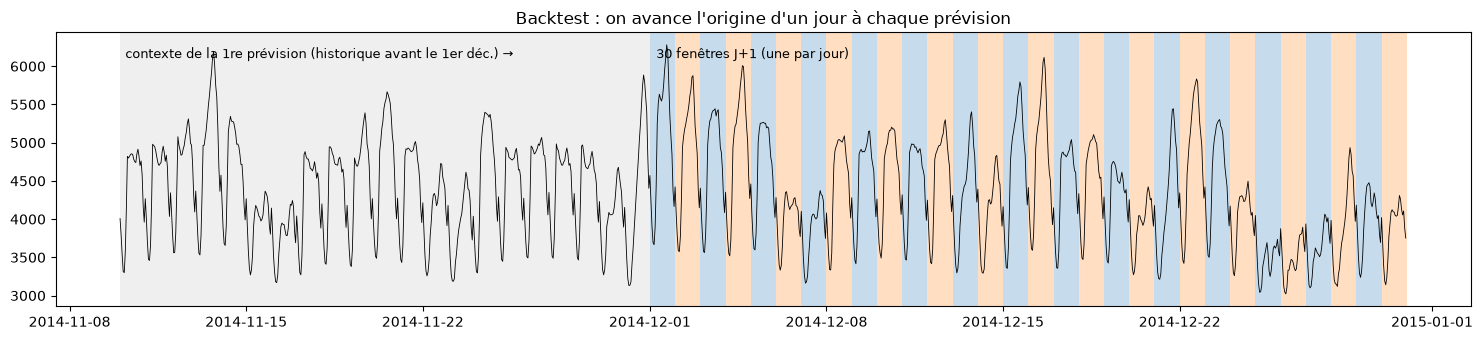

In [27]:
# Schéma du backtest : contexte de la 1re prévision + les 30 fenêtres de prévision J+1
fig, ax = plt.subplots(figsize=(15, 3.5))
view = df.loc["2014-11-10":]
ax.plot(view.index, view["Demand"], color="k", lw=0.6)
for k, o in enumerate(origins):
    ax.axvspan(dates[o], dates[o] + pd.Timedelta(hours=H), color=["tab:blue", "tab:orange"][k % 2], alpha=0.25, lw=0)
ax.axvspan(view.index[0], dates[origins[0]], color="gray", alpha=0.12, lw=0)
ax.text(view.index[5], ax.get_ylim()[1] * 0.97, "contexte de la 1re prévision (historique avant le 1er déc.) →", va="top", fontsize=9)
ax.text(dates[origins[0]] + pd.Timedelta(hours=6), ax.get_ylim()[1] * 0.97, "30 fenêtres J+1 (une par jour)", va="top", fontsize=9)
ax.set_title("Backtest : on avance l'origine d'un jour à chaque prévision")
plt.tight_layout()
plt.show()

**Métriques** (calculées sur les 720 points prévus de chaque modèle) :
- **MAE** (↓) et **RMSE** (↓) — précision de la prévision ponctuelle (médiane)
- **WQL** (↓) — *Weighted Quantile Loss* moyenne sur les quantiles : évalue toute la distribution prédictive. Pour une prévision ponctuelle, elle se réduit au WAPE.
- **Couverture 80 %** — part des observations dans l'intervalle [q10, q90], idéalement ≈ 80 %

In [28]:
preds   = {}   # nom du modèle -> [N, H] (ponctuel) ou [N, H, Q] (quantiles)
timings = {}   # nom du modèle -> temps d'inférence (s)

q_idx = {q: i for i, q in enumerate(quantile_levels)}

def median(p):
    return p if p.ndim == 2 else p[..., q_idx[0.5]]

def wql(p, y_true=y_true):
    if p.ndim == 2:                                       # prévision ponctuelle -> distribution dégénérée
        p = np.repeat(p[..., None], len(quantile_levels), axis=-1)
    err = y_true[..., None] - p
    q   = np.array(quantile_levels)
    pinball = np.maximum(q * err, (q - 1) * err)
    return np.mean(2 * pinball.sum(axis=(0, 1)) / np.abs(y_true).sum())

def coverage_80(p, y_true=y_true):
    if p.ndim == 2:
        return np.nan
    return np.mean((y_true >= p[..., q_idx[0.1]]) & (y_true <= p[..., q_idx[0.9]]))

def scores(names=None, preds=preds, timings=timings, y_true=y_true):
    rows = {}
    for name in names or preds:
        p = preds[name]
        rows[name] = {
            "MAE":          np.mean(np.abs(y_true - median(p))),
            "RMSE":         np.sqrt(np.mean((y_true - median(p)) ** 2)),
            "WQL":          wql(p, y_true),
            "Couv. 80 %":   coverage_80(p, y_true),
            "Temps (s)":    timings.get(name, np.nan),
        }
    return pd.DataFrame(rows).T

In [29]:
COLORS = {"TS-ICL": "tab:red", "Chronos-2": "tab:green", "TiRex-2": "tab:purple", "Naive J-1": "tab:gray", "Naive J-7": "tab:brown"}

def plot_covariates(ax, t, idx):
    # Température sur un axe secondaire + jours fériés en fond grisé.
    ax2 = ax.twinx()
    ax2.plot(t, X[idx, 0], color="tab:cyan", lw=1, alpha=0.9, label="température (°C)")
    ax2.set_ylabel("°C", color="tab:cyan")
    ax2.tick_params(axis="y", colors="tab:cyan")
    ax.fill_between(t, 0, 1, where=X[idx, 1] > 0, transform=ax.get_xaxis_transform(),
                    color="gold", alpha=0.15, lw=0, label="jour férié")
    return ax2

def plot_window(ax, day, name, n_ctx_days=3, title=None, covariates=False, legend=True):
    # Contexte (n_ctx_days derniers jours) + vérité + prévision médiane et intervalle 10-90 %.
    # covariates=True : ajoute la température (axe de droite) et les jours fériés (fond jaune).
    i  = list(dates[origins].normalize()).index(pd.Timestamp(day))
    o  = origins[i]
    is_point = preds[name].ndim == 2
    p  = preds[name][i]                          # [H] (ponctuel) ou [H, Q]
    t_ctx = dates[o - 24 * n_ctx_days : o]
    t_hor = dates[o : o + H]
    color = COLORS.get(name.split(" +")[0], "tab:blue")

    ax.plot(t_ctx, y[o - 24 * n_ctx_days : o], color="k", lw=1, label="contexte")
    ax.plot(t_hor, y_true[i], color="k", lw=1.5, ls="--", label="vérité")
    if is_point:
        ax.plot(t_hor, p, color=color, lw=2, label=name)
    else:
        ax.fill_between(t_hor, p[:, q_idx[0.1]], p[:, q_idx[0.9]], color=color, alpha=0.25, label="intervalle 80 %")
        ax.plot(t_hor, p[:, q_idx[0.5]], color=color, lw=2, label=f"{name} (médiane)")
    ax.axvline(t_hor[0], color="gray", lw=0.8)
    ax.set_title(title or f"{name} — {pd.Timestamp(day):%a %d %b %Y}")
    ax.tick_params(axis="x", labelrotation=30)

    handles, labels = ax.get_legend_handles_labels()
    if covariates:
        idx = np.arange(o - 24 * n_ctx_days, o + H)
        ax2 = plot_covariates(ax, dates[idx], idx)
        handles, labels = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles, labels = handles + h2, labels + l2
    if legend:
        legend_below(ax, handles, labels)
    return handles, labels

<a id="baselines"></a>

---
## 2. Baselines naïves

Deux prévisions **saisonnières naïves**, très utilisées en pratique et qu'un modèle doit battre pour être utile :
- **Naive J-1** — on répète la veille : $\hat y_{t+h} = y_{t+h-24}$
- **Naive J-7** — on répète le même jour de la semaine précédente : $\hat y_{t+h} = y_{t+h-168}$

In [30]:
preds["Naive J-1"] = np.stack([y[o - 24  : o - 24  + H] for o in origins])   # [N, H]
preds["Naive J-7"] = np.stack([y[o - 168 : o - 168 + H] for o in origins])   # [N, H]

scores(["Naive J-1", "Naive J-7"]).round(3)

,MAE,RMSE,WQL,Couv. 80 %,Temps (s)
Naive J-1,321.060,459.776,0.074,NaN,NaN
Naive J-7,377.907,523.760,0.087,NaN,NaN


<a id="no-covariate"></a>

---
## 3. Forecasting sans covariable

Les trois modèles reçoivent uniquement l'historique de la demande. Chacun a sa propre API, mais le principe est le même : **contexte → quantiles sur l'horizon**.

### 3.1 TS-ICL

Les trois modèles sont chargés depuis le dossier local `checkpoints/` (voir le README). Ils proviennent de Hugging Face : [TS-ICL](https://huggingface.co/taharnbl/TS-ICL), [Chronos-2](https://huggingface.co/amazon/chronos-2), [TiRex-2](https://huggingface.co/NX-AI/TiRex-2).

In [31]:
tsicl = TSICL(model_path=CKPT_DIR / "TS-ICL" / "tsicl-v1.ckpt", allow_auto_download=False)
L = CONTEXT_MAX["TS-ICL"]

t0 = time.perf_counter()
_, q = tsicl.forecast(
    inputs            = make_context(L),    # [N, L]
    prediction_length = H,
    context_length    = L,
    batch_size        = 32,
    device            = device,
    quantile_levels   = quantile_levels,
    denormalize       = True,               # sortie dans l'échelle d'origine
)
timings["TS-ICL"] = time.perf_counter() - t0

preds["TS-ICL"] = q.cpu().numpy()           # [N, H, Q]
print(f"TS-ICL    : {preds['TS-ICL'].shape}  ({timings['TS-ICL']:.1f} s)")

TS-ICL    : (30, 24, 9)  (47.5 s)


### 3.2 Chronos-2

In [32]:
chronos = Chronos2Pipeline.from_pretrained(CKPT_DIR / "chronos-2", device_map=device)
L = CONTEXT_MAX["Chronos-2"]

t0 = time.perf_counter()
q, _ = chronos.predict_quantiles(
    inputs            = make_context(L)[:, None, :],   # [N, 1, L] : (batch, variables, temps)
    prediction_length = H,
    quantile_levels   = quantile_levels,
)
timings["Chronos-2"] = time.perf_counter() - t0

# q : liste de N tenseurs [1, H, Q]
preds["Chronos-2"] = np.stack([qi[0].cpu().numpy() for qi in q])   # [N, H, Q]
print(f"Chronos-2 : {preds['Chronos-2'].shape}  ({timings['Chronos-2']:.1f} s)")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 : (30, 24, 9)  (6.1 s)


### 3.3 TiRex-2

TiRex-2 prend une liste de `TimeseriesType` (une par série), chacun contenant la cible et d'éventuelles covariables.

Par défaut, TiRex-2 ne lit que les **2 048 derniers pas** de l'historique (le reste est ignoré). Le modèle a été post-entraîné jusqu'à **8 192 pas** : on relève donc ce réglage après chargement ([issue #53](https://github.com/NX-AI/tirex-2/issues/53)).

> Sur GPU, TiRex-2 compile un kernel CUDA au premier appel (nécessite `nvcc`). Sur CPU, rien à faire.

In [33]:
tirex = load_model(CKPT_DIR / "TiRex-2", device=device)
tirex.model.context_len = 8192   # 2 048 par défaut
L = CONTEXT_MAX["TiRex-2"]

series = [
    TimeseriesType(target=torch.tensor(c)[None], past_covariates=None, future_covariates=None)   # target : [1, L]
    for c in make_context(L)
]

t0 = time.perf_counter()
f = tirex.forecast(series, prediction_length=H, output_type="numpy")
timings["TiRex-2"] = time.perf_counter() - t0

# f : liste de N tableaux [1, Q, H]
preds["TiRex-2"] = np.stack([fi[0].T for fi in f])   # [N, H, Q]
print(f"TiRex-2   : {preds['TiRex-2'].shape}  ({timings['TiRex-2']:.1f} s)")

TiRex-2   : (30, 24, 9)  (2.2 s)


### 3.4 Visualisation

Une fenêtre de prévision pour chaque modèle (avec les 3 jours de contexte précédents) :

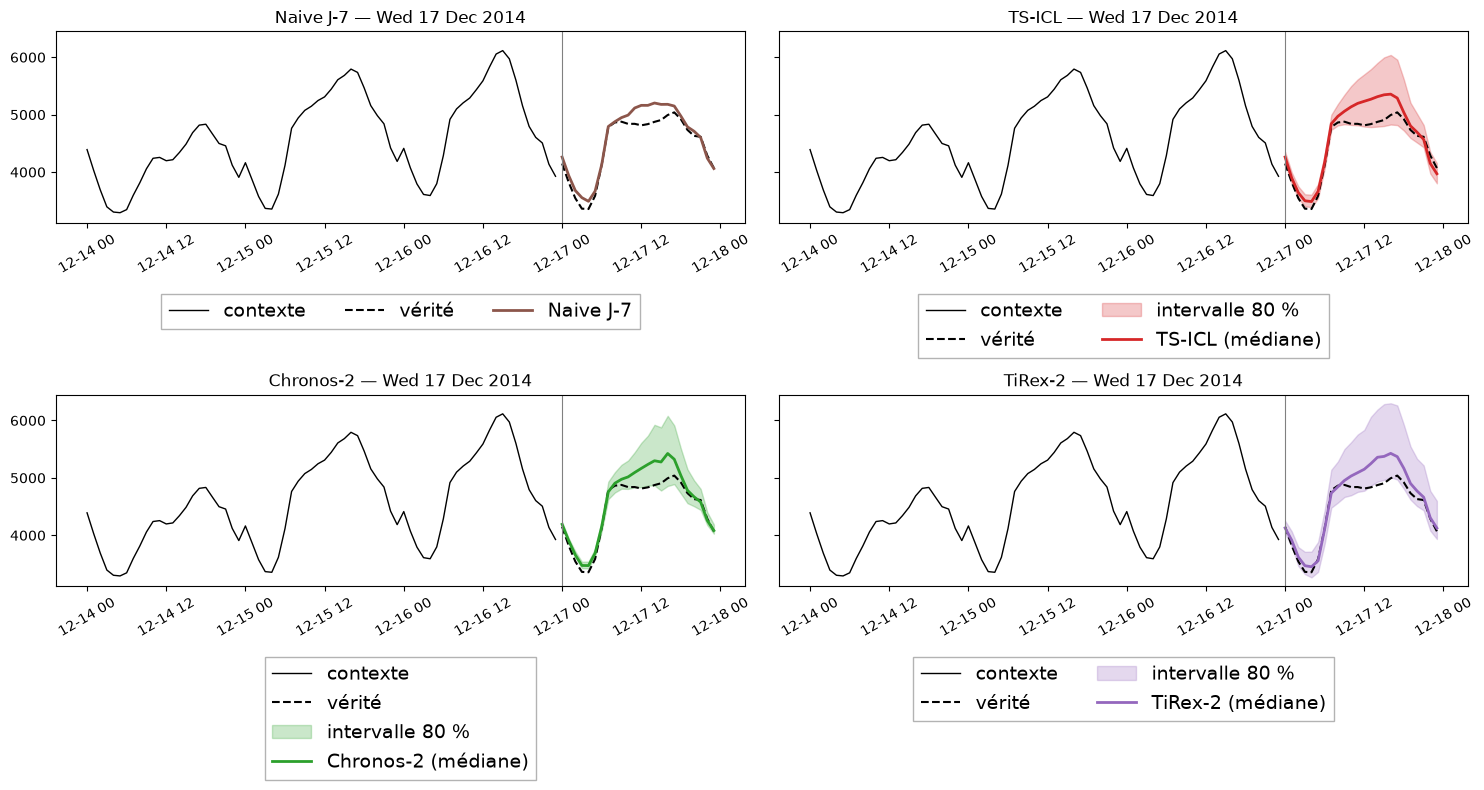

In [34]:
DAY = "2014-12-17"

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
for ax, name in zip(axes.flat, ["Naive J-7", "TS-ICL", "Chronos-2", "TiRex-2"]):
    plot_window(ax, DAY, name)
plt.tight_layout()
plt.show()

Puis les 30 prévisions J+1 mises bout à bout sur le mois de décembre. Le dernier panneau montre les covariables : les plus grosses erreurs coïncident avec les **pics de chaleur** et les **jours fériés** (Noël, Boxing Day), information que les modèles n'ont pas encore.

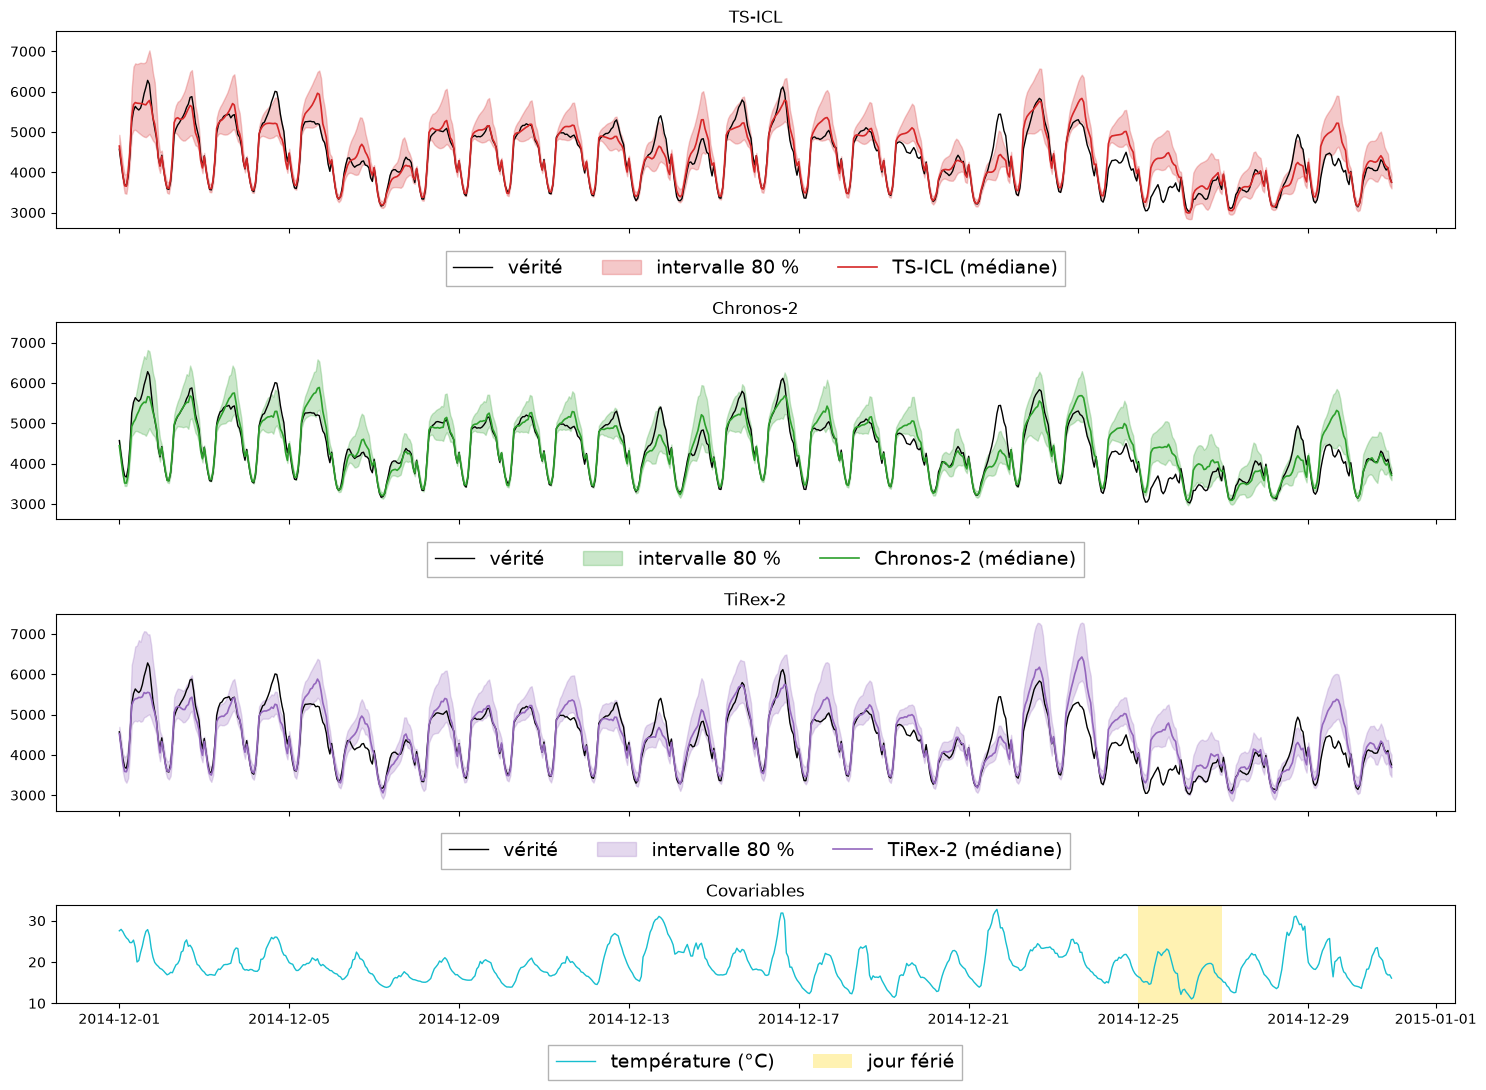

In [35]:
def plot_backtest(preds, origins, names, reference=None):
    # Les prévisions J+1 mises bout à bout + un panneau avec les covariables.
    # reference : prévisions optionnelles dont on trace la médiane en pointillés (ex. sans covariable).
    idx = np.arange(origins[0], origins[-1] + H)
    t   = dates[idx]
    fig, axes = plt.subplots(len(names) + 1, 1, figsize=(15, 3 * len(names) + 2), sharex=True,
                             gridspec_kw={"height_ratios": [3] * len(names) + [1.5]})
    for ax, name in zip(axes, names):
        if ax is not axes[0]:
            ax.sharey(axes[0])
        base = name.split(" +")[0]
        p = preds[name].reshape(-1, len(quantile_levels))       # [N*H, Q]
        ax.plot(t, y[idx], color="k", lw=1, label="vérité")
        if reference is not None:
            ax.plot(t, median(reference[base]).ravel(), color="gray", lw=1, ls=":", label="sans covariable")
        ax.fill_between(t, p[:, q_idx[0.1]], p[:, q_idx[0.9]], color=COLORS[base], alpha=0.25, label="intervalle 80 %")
        ax.plot(t, p[:, q_idx[0.5]], color=COLORS[base], lw=1.2, label=f"{name} (médiane)")
        ax.set_title(name)
        legend_below(ax)

    ax = axes[-1]
    ax.plot(t, X[idx, 0], color="tab:cyan", lw=1, label="température (°C)")
    ax.fill_between(t, 0, 1, where=X[idx, 1] > 0, transform=ax.get_xaxis_transform(),
                    color="gold", alpha=0.3, lw=0, label="jour férié")
    ax.set_title("Covariables")
    legend_below(ax)
    plt.tight_layout()
    plt.show()

plot_backtest(preds, origins, TSFMS)

### 3.5 Résultats

In [36]:
scores().round(3).style.highlight_min(subset=["MAE", "RMSE", "WQL"], color="#5727F5").format(precision=3)

,MAE,RMSE,WQL,Couv. 80 %,Temps (s)
Naive J-1,321.060,459.776,0.074,nan,nan
Naive J-7,377.907,523.760,0.087,nan,nan
TS-ICL,193.557,291.690,0.036,0.769,47.478
Chronos-2,199.226,300.913,0.036,0.708,6.081
TiRex-2,226.364,344.684,0.044,0.743,2.224


<a id="covariates"></a>

---
## 4. Forecasting avec covariables

On fournit maintenant `Temperature` et `Holiday` **sur le contexte et sur l'horizon** (covariables *futures connues*).

> ⚠️ On utilise ici la température **observée** sur l'horizon (oracle). En opérationnel, on utiliserait une **prévision météo** : les gains obtenus ci-dessous sont donc optimistes.

Chaque modèle a son propre format :

| Modèle | Format des covariables |
|---|---|
| TS-ICL | `covars` : tableau `[N, L+H, K]` |
| Chronos-2 | dictionnaires `past_covariates` (longueur `L`) et `future_covariates` (longueur `H`) |
| TiRex-2 | `future_covariates` : tenseur `[K, L+H]` dans chaque `TimeseriesType` |

`make_covars(L)` (défini en partie 1) renvoie les covariables sur le contexte **et** l'horizon : `[N, L+H, K]` avec `K = 2`.

### 4.1 TS-ICL

In [37]:
L = CONTEXT_MAX["TS-ICL"]

t0 = time.perf_counter()
_, q = tsicl.forecast(
    inputs            = make_context(L),
    prediction_length = H,
    context_length    = L,
    covars            = make_covars(L),     # [N, L+H, K]
    batch_size        = 32,
    device            = device,
    quantile_levels   = quantile_levels,
    denormalize       = True,
)
timings["TS-ICL + cov"] = time.perf_counter() - t0
preds["TS-ICL + cov"] = q.cpu().numpy()

### 4.2 Chronos-2

In [38]:
L = CONTEXT_MAX["Chronos-2"]
context, covars = make_context(L), make_covars(L)

inputs = [
    {
        "target":            context[i],
        "past_covariates":   {"Temperature": covars[i, :L, 0], "Holiday": covars[i, :L, 1]},
        "future_covariates": {"Temperature": covars[i, L:, 0], "Holiday": covars[i, L:, 1]},
    }
    for i in range(len(origins))
]

t0 = time.perf_counter()
q, _ = chronos.predict_quantiles(inputs=inputs, prediction_length=H, quantile_levels=quantile_levels)
timings["Chronos-2 + cov"] = time.perf_counter() - t0
preds["Chronos-2 + cov"] = np.stack([qi[0].cpu().numpy() for qi in q])

### 4.3 TiRex-2

In [39]:
L = CONTEXT_MAX["TiRex-2"]
context, covars = make_context(L), make_covars(L)

series_cov = [
    TimeseriesType(
        target            = torch.tensor(context[i])[None],   # [1, L]
        past_covariates   = None,
        future_covariates = torch.tensor(covars[i].T),        # [K, L+H]
    )
    for i in range(len(origins))
]

t0 = time.perf_counter()
f = tirex.forecast(series_cov, prediction_length=H, output_type="numpy")
timings["TiRex-2 + cov"] = time.perf_counter() - t0
preds["TiRex-2 + cov"] = np.stack([fi[0].T for fi in f])

### 4.4 Visualisation : sans vs avec covariables

Deux journées où les covariables devraient compter :
- **dimanche 21 décembre** — pic de chaleur (~33 °C)
- **vendredi 26 décembre** — *Boxing Day*, jour férié

Température en cyan (axe de droite), jours fériés en fond jaune.

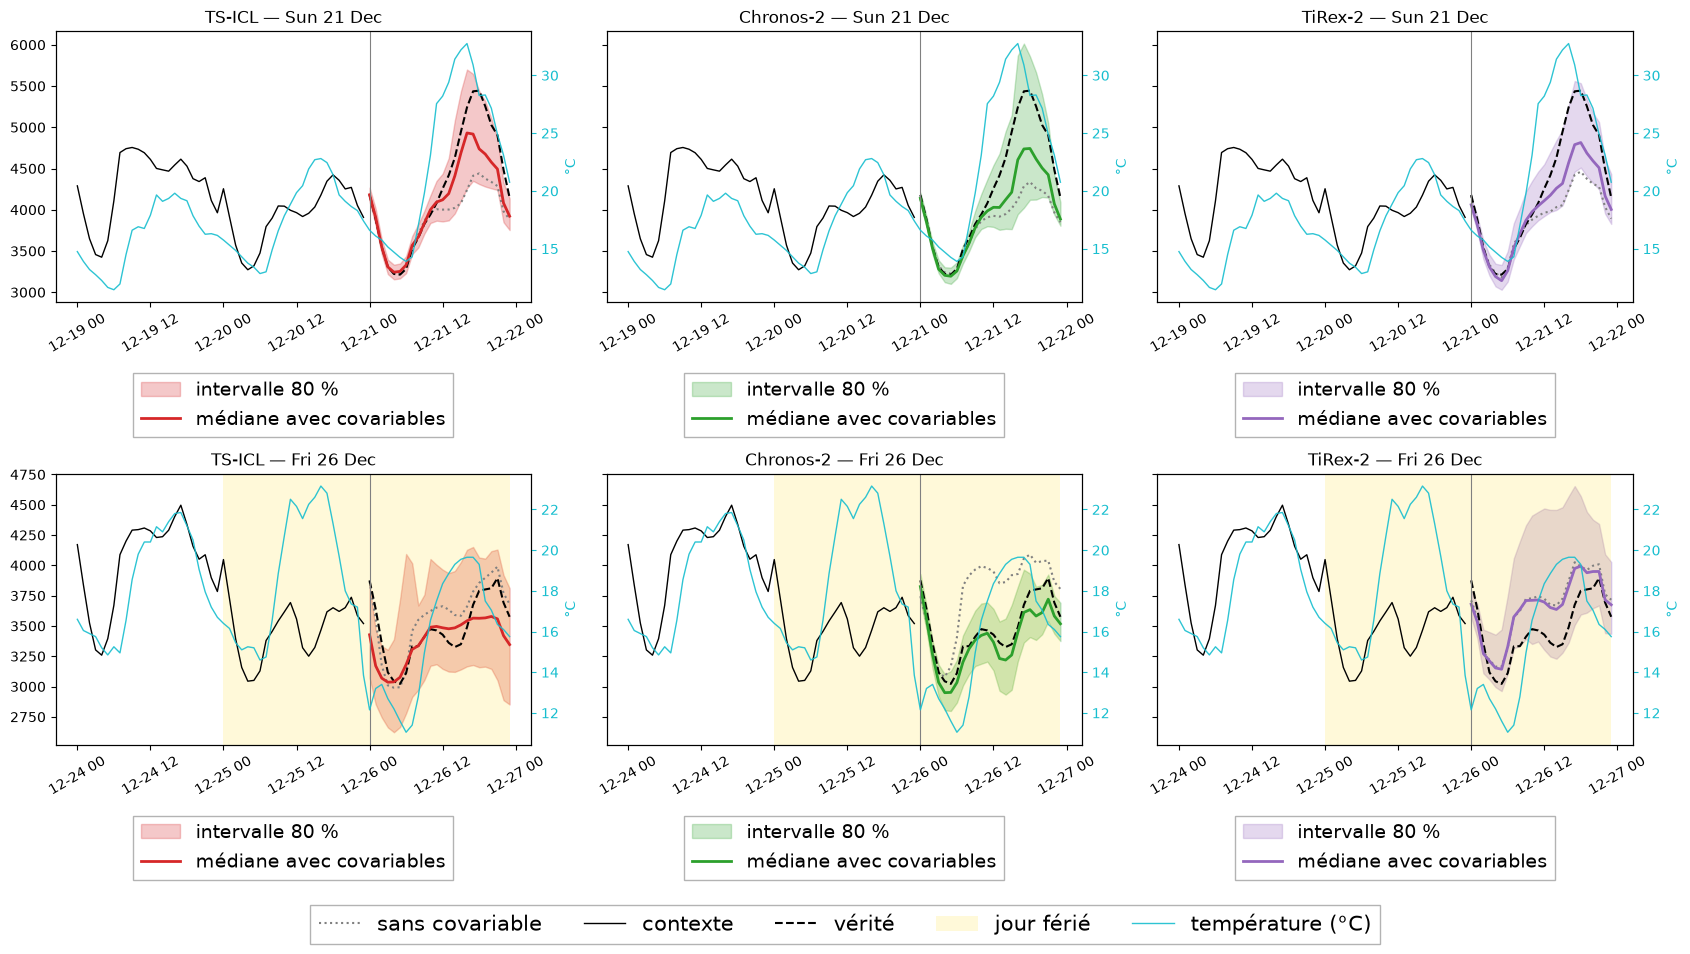

In [40]:
DAYS = ["2014-12-21", "2014-12-26"]

fig, axes = plt.subplots(len(DAYS), len(TSFMS), figsize=(17, 9), sharey="row")
for r, day in enumerate(DAYS):
    i = list(dates[origins].normalize()).index(pd.Timestamp(day))
    t_hor = dates[origins[i] : origins[i] + H]
    for c, name in enumerate(TSFMS):
        ax = axes[r, c]
        ax.plot(t_hor, median(preds[name])[i], color="gray", lw=1.5, ls=":", label="sans covariable")
        h, l = plot_window(ax, day, f"{name} + cov", n_ctx_days=2, title=f"{name} — {pd.Timestamp(day):%a %d %b}",
                           covariates=True, legend=False)
        legend_below(ax, h[-4:-2], ["intervalle 80 %", "médiane avec covariables"])
plt.tight_layout()
fig.legend(h[:3] + h[-2:], ["sans covariable", "contexte", "vérité", "jour férié", "température (°C)"],
           loc="upper center", ncol=5, fontsize=15, bbox_to_anchor=(0.5, 0))   # légende commune, sous la figure
plt.show()

<a id="context-length"></a>

---
## 5. Influence de la taille de contexte

Combien d'historique faut-il donner aux modèles ? On refait le backtest **sans covariable** en faisant varier `L` de 128 h (~5 jours) jusqu'au contexte max de chaque modèle.

In [41]:
CONTEXT_GRID = [128, 256, 512, 1024, 2048, 4096, 8192]

def forecast(name, L, origins=origins, covariates=False):
    # Mêmes appels qu'en parties 3 et 4, pour une longueur de contexte L et des origines données. Renvoie [N, H, Q].
    context = make_context(L, origins)
    covars  = make_covars(L, origins) if covariates else None
    if name == "TS-ICL":
        _, q = tsicl.forecast(inputs=context, prediction_length=H, context_length=L, covars=covars, batch_size=32,
                              device=device, quantile_levels=quantile_levels, denormalize=True)
        return q.cpu().numpy()
    if name == "Chronos-2":
        if covariates:
            inputs = [{"target":            context[i],
                       "past_covariates":   {"Temperature": covars[i, :L, 0], "Holiday": covars[i, :L, 1]},
                       "future_covariates": {"Temperature": covars[i, L:, 0], "Holiday": covars[i, L:, 1]}}
                      for i in range(len(origins))]
        else:
            inputs = context[:, None, :]
        q, _ = chronos.predict_quantiles(inputs=inputs, prediction_length=H, quantile_levels=quantile_levels)
        return np.stack([qi[0].cpu().numpy() for qi in q])
    if name == "TiRex-2":
        series = [TimeseriesType(target            = torch.tensor(context[i])[None],
                                 past_covariates   = None,
                                 future_covariates = torch.tensor(covars[i].T) if covariates else None)
                  for i in range(len(origins))]
        f = tirex.forecast(series, prediction_length=H, output_type="numpy")
        return np.stack([fi[0].T for fi in f])

rows = []
for name in TSFMS:
    for L in [l for l in CONTEXT_GRID if l <= CONTEXT_MAX[name]]:
        t0 = time.perf_counter()
        p  = forecast(name, L)
        dt = time.perf_counter() - t0
        rows.append({"Modèle": name, "L": L, "MAE": np.mean(np.abs(y_true - median(p))), "WQL": wql(p), "Temps (s)": dt})
        print(f"{name:<10} L={L:>5}  MAE={rows[-1]['MAE']:6.1f}  WQL={rows[-1]['WQL']:.3f}  ({dt:.1f} s)")

ctx_study = pd.DataFrame(rows)

TS-ICL     L=  128  MAE= 231.0  WQL=0.041  (0.7 s)
TS-ICL     L=  256  MAE= 195.4  WQL=0.037  (1.2 s)
TS-ICL     L=  512  MAE= 188.9  WQL=0.035  (2.6 s)
TS-ICL     L= 1024  MAE= 192.5  WQL=0.036  (5.7 s)
TS-ICL     L= 2048  MAE= 197.5  WQL=0.037  (14.2 s)
TS-ICL     L= 4096  MAE= 193.6  WQL=0.036  (46.5 s)
Chronos-2  L=  128  MAE= 239.7  WQL=0.044  (0.2 s)
Chronos-2  L=  256  MAE= 218.2  WQL=0.039  (0.3 s)
Chronos-2  L=  512  MAE= 201.0  WQL=0.037  (0.4 s)
Chronos-2  L= 1024  MAE= 196.7  WQL=0.036  (0.8 s)
Chronos-2  L= 2048  MAE= 193.8  WQL=0.035  (1.6 s)
Chronos-2  L= 4096  MAE= 199.7  WQL=0.036  (2.9 s)
Chronos-2  L= 8192  MAE= 199.2  WQL=0.036  (6.5 s)
TiRex-2    L=  128  MAE= 256.5  WQL=0.047  (2.8 s)
TiRex-2    L=  256  MAE= 218.1  WQL=0.041  (2.7 s)
TiRex-2    L=  512  MAE= 232.7  WQL=0.044  (2.4 s)
TiRex-2    L= 1024  MAE= 220.2  WQL=0.042  (2.5 s)
TiRex-2    L= 2048  MAE= 219.5  WQL=0.042  (2.3 s)
TiRex-2    L= 4096  MAE= 234.4  WQL=0.045  (2.4 s)
TiRex-2    L= 8192  MAE= 226.

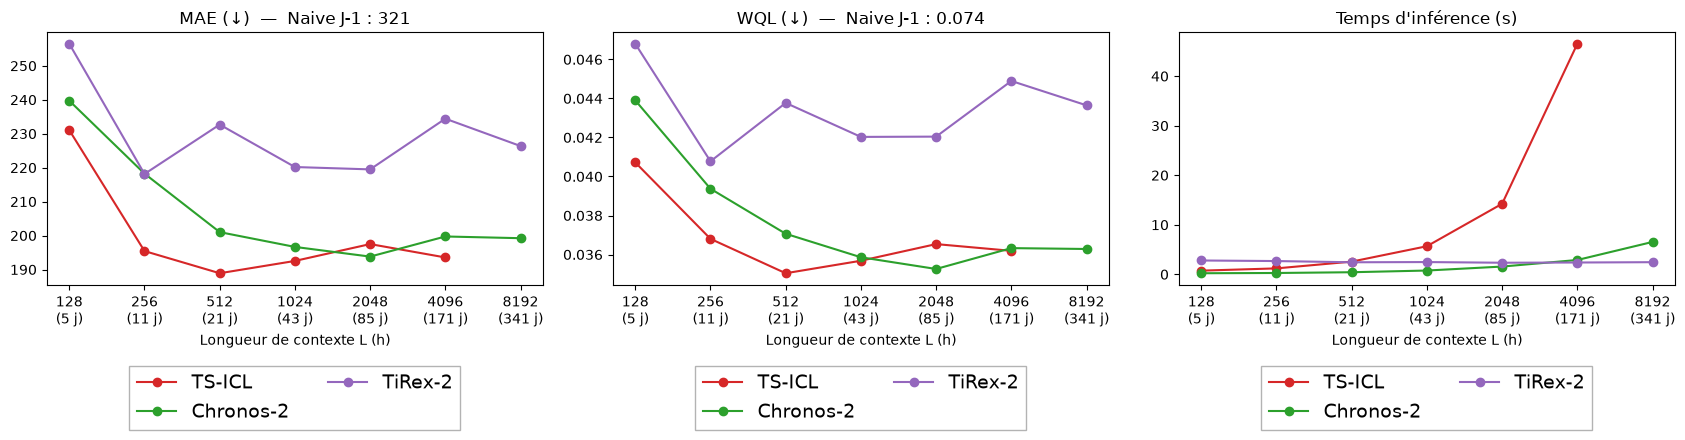

Modèle,TS-ICL,Chronos-2,TiRex-2
L,,,
128,231.000000,239.699997,256.500000
256,195.399994,218.199997,218.100006
512,188.899994,201.000000,232.699997
1024,192.500000,196.699997,220.199997
2048,197.500000,193.800003,219.500000
4096,193.600006,199.699997,234.399994
8192,NaN,199.199997,226.399994


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for name, g in ctx_study.groupby("Modèle", sort=False):
    for ax, metric in zip(axes, ["MAE", "WQL", "Temps (s)"]):
        ax.plot(g["L"], g[metric], "o-", color=COLORS[name], label=name)

baseline = scores(["Naive J-1"]).iloc[0]
titles   = [f"MAE (↓)  —  Naive J-1 : {baseline['MAE']:.0f}", f"WQL (↓)  —  Naive J-1 : {baseline['WQL']:.3f}", "Temps d'inférence (s)"]

for ax, metric in zip(axes, titles):
    ax.set_xscale("log", base=2)
    ax.set_xticks(CONTEXT_GRID, [f"{l}\n({l / 24:.0f} j)" for l in CONTEXT_GRID])
    ax.set_xlabel("Longueur de contexte L (h)")
    ax.set_title(metric)
    legend_below(ax)
plt.tight_layout()
plt.show()

ctx_study.pivot(index="L", columns="Modèle", values="MAE")[TSFMS].round(1)

#### Ce qu'on observe

- **Trop peu d'historique pénalise tous les modèles** : avec 128 h (~5 jours), le cycle hebdomadaire n'est même pas observé en entier.
- **Au-delà de ~512–2 048 h, les performances plafonnent** : donner le contexte max n'améliore pas systématiquement la prévision J+1. Sur 30 fenêtres, des écarts de quelques unités de MAE relèvent du bruit.
- **Le coût n'est pas le même** : le temps de TS-ICL croît fortement avec `L` (attention sur tous les pas de temps), celui de Chronos-2 croît modérément, et celui de TiRex-2 est quasi constant (le contexte est toujours complété jusqu'à `context_len`).
- **TiRex-2** : relever `context_len` de 2 048 (défaut) à 8 192 n'apporte rien sur ce jeu de données, la prévision est même un peu moins bonne avec 8 192 h d'historique.

> En pratique, la longueur de contexte est un **hyperparamètre** à régler par backtest, en arbitrant précision et temps de calcul.

<a id="results"></a>

---
## 6. Bilan (décembre 2014)

In [22]:
results = scores().sort_values("MAE")
results.style.highlight_min(subset=["MAE", "RMSE", "WQL"], color="#5727F5").format(precision=3)

,MAE,RMSE,WQL,Couv. 80 %,Temps (s)
TS-ICL + cov,162.358,242.186,0.029,0.838,52.146
Chronos-2 + cov,167.443,248.922,0.030,0.771,20.044
TS-ICL,193.557,291.690,0.036,0.769,52.681
Chronos-2,199.226,300.913,0.036,0.708,6.935
TiRex-2 + cov,209.958,323.639,0.040,0.768,15.801
TiRex-2,226.364,344.684,0.044,0.743,7.732
Naive J-1,321.060,459.776,0.074,nan,nan
Naive J-7,377.907,523.760,0.087,nan,nan


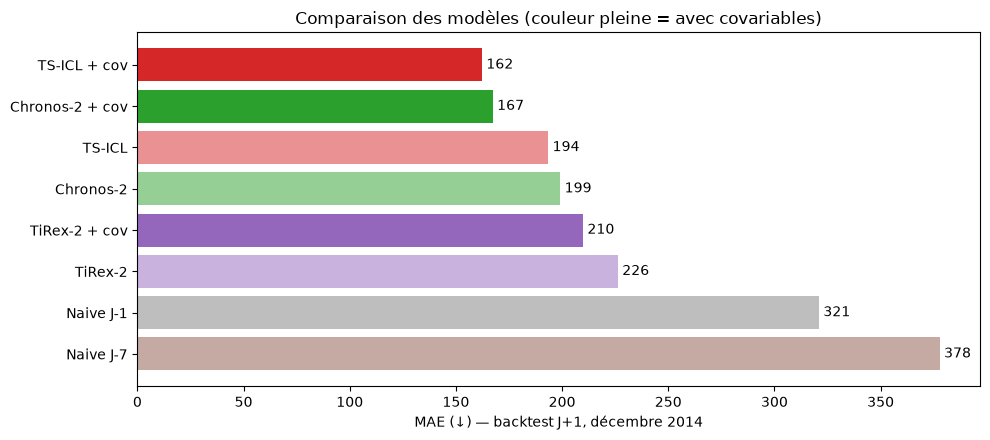

In [25]:
fig, ax = plt.subplots(figsize=(10, 4.5))
names  = results.index[::-1]
colors = [COLORS.get(n.split(" +")[0]) for n in names]
bars   = ax.barh(names, results.loc[names, "MAE"], color=colors)
for bar, n in zip(bars, names):
    bar.set_alpha(1.0 if "+ cov" in n else 0.5)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_xlabel("MAE (↓) — backtest J+1, décembre 2014")
ax.set_title("Comparaison des modèles (couleur pleine = avec covariables)")
plt.tight_layout()
plt.show()

#### À retenir

- **Zero-shot** : aucun des trois TSFMs n'a vu ces données, et quelques lignes de code suffisent pour obtenir des prévisions probabilistes.
- Sans covariable, les TSFMs battent déjà nettement les baselines saisonnières naïves.
- Les **covariables** (température, jours fériés) apportent un gain supplémentaire important, en particulier lors des pics de chaleur et des jours fériés.
- Les trois modèles renvoient des **quantiles** : on évalue la distribution (WQL, couverture), pas seulement la médiane.